# Formative 2: Modeling Human Activity States Using Hidden Markov Models

## Project Overview
A Hidden Markov Model (HMM) is constructed to infer human activity states
(Still, Standing, Walking, Jumping) from raw smartphone accelerometer and gyroscope
data. In real-world systems such as wearables and smart home sensors, the true
activity being performed is "hidden" — only noisy sensor signals are directly
observable. An HMM is well suited to this setting because it explicitly models:
- **What sensor patterns look like during each activity** (emission probabilities)
- **How activities tend to transition over time** (e.g. standing → walking is common,
  standing → jumping directly is rare) (transition probabilities)

## Data Collection
- Device: iPhone, Sensor Logger app
- Sensors: Accelerometer (x, y, z), Gyroscope (x, y, z)
- Sample rate: **50 Hz** (one sample every 20 ms)
- Activities: Still (phone on table), Standing (phone at waist), Walking (phone at
  waist), Jumping (phone at waist)
- 15 takes per activity × 4 activities = **60 takes total**; each take is approximately
  10 seconds, giving **~150 seconds (~2.5 minutes) of labeled data per activity**
  and approximately **10 minutes of recording in total**.

## Pipeline
1. Load and merge accelerometer + gyroscope readings per take
2. Segment each take into fixed-length windows and extract time-domain and
   frequency-domain features
3. Build and train a Hidden Markov Model from scratch (Viterbi for decoding,
   Baum-Welch for parameter estimation), validated against the `hmmlearn` library
4. Evaluate the trained model on unseen recordings (sensitivity, specificity,
   accuracy, confusion matrix)
5. Visualize transition probabilities, decoded activity sequences, and emission
   distributions


In [1]:
import os

# Local path — notebook is run from the Formative2_project directory
DATA_PATH = os.path.join(os.getcwd(), 'Formative2_data')
OUTPUT_PATH = os.path.join(os.getcwd(), 'outputs')
os.makedirs(OUTPUT_PATH, exist_ok=True)

print('Data path:', DATA_PATH)
print('Contents:')
for root, dirs, files in os.walk(DATA_PATH):
    print(root, len(files), 'files')


Data path: /Users/paula/Desktop/Formative2_project/Formative2_data
Contents:
/Users/paula/Desktop/Formative2_project/Formative2_data 0 files
/Users/paula/Desktop/Formative2_project/Formative2_data/test 12 files
/Users/paula/Desktop/Formative2_project/Formative2_data/walking 45 files
/Users/paula/Desktop/Formative2_project/Formative2_data/jumping 45 files
/Users/paula/Desktop/Formative2_project/Formative2_data/standing 45 files
/Users/paula/Desktop/Formative2_project/Formative2_data/still 45 files


In [2]:
import pandas as pd

sample = pd.read_csv(os.path.join(DATA_PATH, 'walking', 'walking_01_accel.csv'))
print(sample.shape)
print(sample.columns.tolist())
sample.head()


(511, 5)
['time', 'seconds_elapsed', 'z', 'y', 'x']


,time,seconds_elapsed,z,y,x
0,1782814914855626000,0.050626,-0.465548,-0.747020,0.344199
1,1782814914875709200,0.070709,-0.598837,-0.747150,0.193009
2,1782814914895792000,0.090792,-0.900659,-0.651575,0.139112
3,1782814914915875000,0.110875,-1.317428,-0.438852,0.212031
4,1782814914935958000,0.130958,-1.504237,-0.308407,0.158384


In [3]:
sample_gyro = pd.read_csv(os.path.join(DATA_PATH, 'walking', 'walking_01_gyro.csv'))
print(sample_gyro.shape)
print(sample_gyro.columns.tolist())
sample_gyro.head()


(511, 5)
['time', 'seconds_elapsed', 'z', 'y', 'x']


,time,seconds_elapsed,z,y,x
0,1782814914855626000,0.050626,0.138773,-0.261816,-0.253629
1,1782814914875709200,0.070709,0.092453,-0.347506,-0.301857
2,1782814914895792000,0.090792,0.031860,-0.363932,-0.346203
3,1782814914915875000,0.110875,0.022365,-0.306202,-0.305442
4,1782814914935958000,0.130958,0.042758,-0.203529,-0.144727


## Loading and Merging Sensor Data
Each recorded take (15 per activity × 4 activities = 60 takes total) is loaded from
disk. Accelerometer and gyroscope readings are merged by nearest-timestamp alignment,
and each row is tagged with its ground-truth activity label and take identifier,
producing a single combined dataframe for the full training dataset.


In [4]:
import pandas as pd
import numpy as np
import os
import glob

def load_all_takes(base_path=None):
    if base_path is None:
        base_path = DATA_PATH
    activities = ['still', 'standing', 'walking', 'jumping']
    all_takes = []

    for activity in activities:
        accel_files = sorted(glob.glob(f'{base_path}/{activity}/{activity}_*_accel.csv'))
        if not accel_files:
            print(f'WARNING: no accel files found for {activity} — folder missing or empty')

        for accel_path in accel_files:
            take_id = accel_path.split('_accel.csv')[0].split('/')[-1]
            gyro_path = accel_path.replace('_accel.csv', '_gyro.csv')

            if not os.path.exists(gyro_path):
                print(f'Missing gyro for {take_id}, skipping')
                continue

            if os.path.getsize(gyro_path) == 0 or os.path.getsize(accel_path) == 0:
                print(f'Empty file for {take_id}, skipping')
                continue

            try:
                accel = pd.read_csv(accel_path)
                gyro = pd.read_csv(gyro_path)
            except Exception as e:
                print(f'Could not read {take_id}: {e}, skipping')
                continue

            if accel.empty or gyro.empty:
                print(f'Empty dataframe for {take_id}, skipping')
                continue

            accel = accel.rename(columns={'x':'accel_x','y':'accel_y','z':'accel_z'})
            gyro = gyro.rename(columns={'x':'gyro_x','y':'gyro_y','z':'gyro_z'})

            merged = pd.merge_asof(
                accel.sort_values('seconds_elapsed'),
                gyro[['seconds_elapsed','gyro_x','gyro_y','gyro_z']].sort_values('seconds_elapsed'),
                on='seconds_elapsed',
                direction='nearest'
            )

            merged['activity'] = activity
            merged['take_id'] = take_id
            all_takes.append(merged)

    if not all_takes:
        raise RuntimeError(f'No takes found under {base_path}')
    full_df = pd.concat(all_takes, ignore_index=True)
    return full_df

df = load_all_takes()
print(df.shape)
print(df['activity'].value_counts())
df.head()


(30821, 10)
activity
jumping     7766
standing    7726
walking     7689
still       7640
Name: count, dtype: int64


,time,seconds_elapsed,accel_z,accel_y,accel_x,gyro_x,gyro_y,gyro_z,activity,take_id
0,1782811935648554500,0.064554,-0.028286,0.280541,0.053938,0.000441,-0.001573,-0.005111,still,still_01
1,1782811935668637400,0.084637,-0.014521,-0.189687,0.083539,-0.000661,-0.000167,0.005432,still,still_01
2,1782811935688720400,0.104720,-0.021402,-0.021550,0.021383,0.000731,-0.000363,-0.004564,still,still_01
3,1782811935708802600,0.124802,-0.028885,-0.106381,-0.054864,-0.001423,-0.000426,0.003530,still,still_01
4,1782811935728885500,0.144885,-0.034125,0.231830,-0.084224,-0.000442,0.000776,-0.000395,still,still_01


## Windowing and Feature Extraction

Each take is segmented into non-overlapping 1-second windows (50 samples at 50 Hz).
A 1-second window is long enough to capture a complete walking stride or jump arc,
yet short enough to remain within a single activity period.

The following features are extracted from each window. Each is chosen because it
carries distinct discriminative information across the four activity classes:

**Time-domain features**
- **Acceleration mean (per axis — x, y, z):** Captures the mean gravitational and
  positional component across the window. When the phone lies flat on a table (Still),
  means are near-zero on the horizontal axes; walking and jumping produce sustained
  axial offsets from consistent posture and impact phases.
- **Acceleration standard deviation (per axis):** Quantifies motion variability.
  Still and Standing produce near-zero variance; Walking generates moderate rhythmic
  variance; Jumping produces high variance from impulsive ground-contact forces.
- **Gyroscope mean (per axis):** Measures the mean rotational rate. Minimal for Still
  and Standing; elevated for Walking (consistent trunk rotation) and Jumping (large
  impulsive rotations at take-off and landing).
- **Gyroscope standard deviation (per axis):** Captures rotational variability across
  the window, distinguishing the irregular bursts of rotation in Jumping from the
  steady periodicity of Walking.
- **Signal Magnitude Area — accelerometer (SMA):** Sums absolute accelerations across
  all three axes into a single scalar for total movement intensity. SMA increases
  monotonically from Still → Standing → Walking → Jumping, making it one of the
  strongest single-feature discriminators.
- **Signal Magnitude Area — gyroscope (SMA):** Rotational analogue of accel SMA.
  Distinguishes activities with substantial whole-body rotation (Walking, Jumping)
  from stationary postures (Still, Standing).

**Frequency-domain features (FFT of resultant acceleration magnitude)**
- **Dominant frequency:** The frequency bin with peak power (excluding DC). Walking
  has a characteristic stride cadence of approximately 1.5–2 Hz; Jumping appears in a
  similar range but with much higher amplitude; Still and Standing have no dominant
  periodic component, yielding a near-zero dominant frequency.
- **Spectral energy:** Total signal power across the frequency spectrum (sum of squared
  FFT magnitudes). Jumping generates very high spectral energy from large, abrupt
  accelerations; Still produces near-zero energy. This feature provides a continuous
  scale of overall activity intensity that complements the time-domain SMA.

All 16 features are then normalized with Z-score scaling (described in the following
section) before being passed to the HMM.


In [5]:
import numpy as np
from scipy.fft import rfft, rfftfreq

WINDOW_SIZE = 50  # 1 second at 50Hz
SAMPLE_RATE = 50

def extract_features(window):
    """Compute time-domain and frequency-domain features for one window."""
    accel_cols = ['accel_x', 'accel_y', 'accel_z']
    gyro_cols = ['gyro_x', 'gyro_y', 'gyro_z']

    feats = {}

    # Time-domain: mean and std per axis (accel + gyro)
    for col in accel_cols + gyro_cols:
        feats[f'{col}_mean'] = window[col].mean()
        feats[f'{col}_std'] = window[col].std()

    feats['accel_sma'] = (window['accel_x'].abs() + window['accel_y'].abs() + window['accel_z'].abs()).sum() / len(window)
    feats['gyro_sma'] = (window['gyro_x'].abs() + window['gyro_y'].abs() + window['gyro_z'].abs()).sum() / len(window)

    accel_mag = np.sqrt(window['accel_x']**2 + window['accel_y']**2 + window['accel_z']**2)
    fft_vals = np.abs(rfft(accel_mag.values - accel_mag.mean()))
    freqs = rfftfreq(len(accel_mag), d=1/SAMPLE_RATE)

    if len(fft_vals) > 1:
        dominant_idx = np.argmax(fft_vals[1:]) + 1
        feats['dominant_freq'] = freqs[dominant_idx]
        feats['spectral_energy'] = np.sum(fft_vals**2)
    else:
        feats['dominant_freq'] = 0
        feats['spectral_energy'] = 0

    return feats

def build_feature_dataset(df, window_size=WINDOW_SIZE):
    """Slide non-overlapping windows over each take and extract features."""
    rows = []

    for take_id, take_df in df.groupby('take_id'):
        take_df = take_df.reset_index(drop=True)
        activity = take_df['activity'].iloc[0]

        n_windows = len(take_df) // window_size
        for i in range(n_windows):
            window = take_df.iloc[i*window_size : (i+1)*window_size]
            feats = extract_features(window)
            feats['activity'] = activity
            feats['take_id'] = take_id
            feats['window_idx'] = i
            rows.append(feats)

    return pd.DataFrame(rows)

feature_df = build_feature_dataset(df)
print(feature_df.shape)
print(feature_df['activity'].value_counts())
feature_df.head()

(599, 19)
activity
jumping     150
standing    150
walking     150
still       149
Name: count, dtype: int64


,accel_x_mean,accel_x_std,accel_y_mean,accel_y_std,accel_z_mean,accel_z_std,gyro_x_mean,gyro_x_std,gyro_y_mean,gyro_y_std,gyro_z_mean,gyro_z_std,accel_sma,gyro_sma,dominant_freq,spectral_energy,activity,take_id,window_idx
0,-0.009474,1.261560,-0.043104,1.432589,-0.360066,2.940673,-0.246686,1.186942,-0.186449,2.180487,-0.046403,0.954355,4.072606,3.254690,3.0,5026.540706,jumping,jumping_01,0
1,-0.439297,1.703034,-0.225832,2.451898,0.192608,7.312834,-0.164267,1.616185,0.249003,1.112021,0.044954,1.057048,9.631110,3.055704,4.0,9484.832767,jumping,jumping_01,1
2,0.261132,2.823406,1.339398,3.032503,0.833168,6.972123,0.026473,2.161459,-0.205314,1.196920,-0.072716,0.911155,11.069463,3.272624,3.0,9686.842665,jumping,jumping_01,2
3,-0.383020,2.723619,-0.443177,2.275926,-1.357048,6.620398,-0.134769,1.719349,0.034143,1.472140,-0.005430,0.929268,9.838778,3.375483,4.0,9628.993033,jumping,jumping_01,3
4,-0.166620,3.465505,1.423087,3.360099,1.444638,11.027794,0.317607,3.126976,0.133363,1.388110,0.069732,1.505343,15.366964,4.472445,5.0,25807.175253,jumping,jumping_01,4


## Feature Normalization
The extracted features span very different numerical scales — standard deviations
sit in the single digits while spectral energy reaches the thousands. Without
normalization, high-magnitude features would dominate the Gaussian emission
log-likelihoods regardless of their actual discriminative value. Z-score
normalization (zero mean, unit variance) is therefore applied to every feature so
that each contributes proportionally during HMM parameter estimation.


In [6]:
from sklearn.preprocessing import StandardScaler

feature_cols = [c for c in feature_df.columns if c not in ['activity', 'take_id', 'window_idx']]

scaler = StandardScaler()
X = scaler.fit_transform(feature_df[feature_cols])

normalized_df = pd.DataFrame(X, columns=feature_cols)
normalized_df['activity'] = feature_df['activity'].values
normalized_df['take_id'] = feature_df['take_id'].values
normalized_df['window_idx'] = feature_df['window_idx'].values

print(normalized_df.shape)
normalized_df.head()

(599, 19)


,accel_x_mean,accel_x_std,accel_y_mean,accel_y_std,accel_z_mean,accel_z_std,gyro_x_mean,gyro_x_std,gyro_y_mean,gyro_y_std,gyro_z_mean,gyro_z_std,accel_sma,gyro_sma,dominant_freq,spectral_energy,activity,take_id,window_idx
0,0.052416,0.765638,-0.322949,0.895498,-0.983243,0.263888,-2.416435,1.469220,-1.637835,3.208094,-0.130008,2.075944,0.317120,2.036929,-0.478729,0.026132,jumping,jumping_01,0
1,-2.117039,1.286425,-0.974252,2.078079,0.749178,1.553840,-1.596314,2.246285,2.259022,1.299931,0.113185,2.383932,1.668564,1.865769,-0.320909,0.452118,jumping,jumping_01,1
2,1.418254,2.608079,4.604745,2.751683,2.757085,1.453318,0.301682,3.233403,-1.806659,1.451551,-0.200054,1.946383,2.018272,2.052355,-0.478729,0.471419,jumping,jumping_01,2
3,-1.832992,2.490364,-1.748942,1.873920,-4.108396,1.349546,-1.302781,2.433045,0.336241,1.943063,-0.020937,2.000704,1.719055,2.140830,-0.320909,0.465892,jumping,jumping_01,3
4,-0.740749,3.365534,4.903041,3.131754,4.673811,2.649893,3.198662,4.981293,1.224158,1.792995,0.179144,3.728417,3.063127,3.084394,-0.163089,2.011700,jumping,jumping_01,4


## Hidden Markov Model: Supervised Initialization and Baum-Welch Training
HMM parameters (transition matrix, Gaussian emission distributions, initial state
probabilities) are initialized directly from the labeled training data — a stable
starting point given the limited dataset size. These estimates are subsequently
refined using the Baum-Welch (EM) algorithm, with log-likelihood tracked at each
iteration and training halted once improvement falls below a convergence threshold.


In [7]:
import numpy as np

np.random.seed(42)

STATES = ['still', 'standing', 'walking', 'jumping']
N_STATES = len(STATES)
state_to_idx = {s: i for i, s in enumerate(STATES)}

feature_cols = [c for c in normalized_df.columns if c not in ['activity', 'take_id', 'window_idx']]
N_FEATURES = len(feature_cols)

# 1. Supervised initialization

def supervised_init(df, feature_cols, states):
    n_states = len(states)
    n_features = len(feature_cols)

    first_windows = df[df['window_idx'] == 0]
    pi = np.zeros(n_states)
    for i, s in enumerate(states):
        pi[i] = (first_windows['activity'] == s).sum()
    pi = pi / pi.sum()

    A = np.zeros((n_states, n_states))
    for take_id, take_df in df.groupby('take_id'):
        take_df = take_df.sort_values('window_idx')
        acts = take_df['activity'].values
        for t in range(len(acts) - 1):
            i = state_to_idx[acts[t]]
            j = state_to_idx[acts[t+1]]
            A[i, j] += 1

    A += 0.1
    A = A / A.sum(axis=1, keepdims=True)

    means = np.zeros((n_states, n_features))
    covs = np.zeros((n_states, n_features))
    for i, s in enumerate(states):
        state_data = df[df['activity'] == s][feature_cols].values
        means[i] = state_data.mean(axis=0)
        covs[i] = state_data.var(axis=0) + 1e-6

    return pi, A, means, covs

pi, A, means, covs = supervised_init(normalized_df, feature_cols, STATES)

print("Initial pi:", pi)
print("\nInitial A:\n", A)
print("\nMeans shape:", means.shape, " Covs shape:", covs.shape)

Initial pi: [0.25 0.25 0.25 0.25]

Initial A:
 [[9.97767857e-01 7.44047619e-04 7.44047619e-04 7.44047619e-04]
 [7.38552437e-04 9.97784343e-01 7.38552437e-04 7.38552437e-04]
 [7.38552437e-04 7.38552437e-04 9.97784343e-01 7.38552437e-04]
 [7.38552437e-04 7.38552437e-04 7.38552437e-04 9.97784343e-01]]

Means shape: (4, 16)  Covs shape: (4, 16)


## Gaussian Emission Model and Viterbi Decoding
Because the features are continuous, each hidden state's emission distribution is
modelled as a diagonal-covariance multivariate Gaussian. Viterbi decoding then
identifies the single most likely hidden-state sequence given a sequence of observed
feature vectors, via dynamic programming carried out entirely in log-space to avoid
numerical underflow.


In [8]:
def gaussian_log_prob(x, mean, var):
    """Log probability of x under a diagonal-covariance Gaussian."""
    return np.sum(-0.5 * np.log(2 * np.pi * var) - 0.5 * ((x - mean) ** 2) / var)

def log_emission_matrix(X, means, covs):
    """Compute log emission probabilities for every observation against every state.
    Returns shape (T, n_states)."""
    T = X.shape[0]
    n_states = means.shape[0]
    log_B = np.zeros((T, n_states))
    for t in range(T):
        for s in range(n_states):
            log_B[t, s] = gaussian_log_prob(X[t], means[s], covs[s])
    return log_B

def viterbi(X, pi, A, means, covs):
    """Decode the most likely hidden state sequence using log-space Viterbi."""
    T = X.shape[0]
    n_states = len(pi)

    log_pi = np.log(pi + 1e-12)
    log_A = np.log(A + 1e-12)
    log_B = log_emission_matrix(X, means, covs)

    delta = np.zeros((T, n_states))
    psi = np.zeros((T, n_states), dtype=int)

    delta[0] = log_pi + log_B[0]

    for t in range(1, T):
        for s in range(n_states):
            scores = delta[t-1] + log_A[:, s]
            psi[t, s] = np.argmax(scores)
            delta[t, s] = np.max(scores) + log_B[t, s]

    states_seq = np.zeros(T, dtype=int)
    states_seq[T-1] = np.argmax(delta[T-1])
    for t in range(T-2, -1, -1):
        states_seq[t] = psi[t+1, states_seq[t+1]]

    return states_seq, delta

# Store full feature matrix for use by downstream cells
X_train = normalized_df[feature_cols].values

true_labels = normalized_df['activity'].map(state_to_idx).values

# Decode each training take separately — same methodology as the test evaluation
take_accs = []
for take_id, take_df in normalized_df.groupby('take_id'):
    take_df = take_df.sort_values('window_idx')
    X_take = take_df[feature_cols].values
    true_take = take_df['activity'].map(state_to_idx).values
    decoded_take, _ = viterbi(X_take, pi, A, means, covs)
    take_accs.append((decoded_take == true_take).mean())

mean_acc = np.mean(take_accs)
print(f"Sanity check - per-take Viterbi accuracy (mean across {len(take_accs)} takes): {mean_acc:.3f}")
print(f"  Min: {min(take_accs):.3f}  Max: {max(take_accs):.3f}")


Sanity check - per-take Viterbi accuracy (mean across 60 takes): 0.973
  Min: 0.900  Max: 1.000


## Baum-Welch Training with Log-Likelihood Convergence
The supervised initialization is refined using the Baum-Welch (EM) algorithm.
At each iteration, the forward-backward procedure (E-step) computes state
posterior probabilities (gamma) and transition posteriors (xi) across all training
sequences. These are used in the M-step to re-estimate the transition matrix,
emission Gaussians, and initial state probabilities. Crucially, the E-step gamma
values are stored and reused directly for the variance M-step, ensuring all
parameter updates are consistent within a single EM iteration. Training halts once
the change in total log-likelihood across all sequences falls below `tol=1e-3`,
indicating convergence.


In [9]:
def forward_backward(X, pi, A, means, covs):
    """Compute forward (alpha) and backward (beta) probabilities in log-space,
    plus gamma (state posteriors) and xi (transition posteriors)."""
    T = X.shape[0]
    n_states = len(pi)

    log_pi = np.log(pi + 1e-12)
    log_A = np.log(A + 1e-12)
    log_B = log_emission_matrix(X, means, covs)

    log_alpha = np.zeros((T, n_states))
    log_alpha[0] = log_pi + log_B[0]
    for t in range(1, T):
        for s in range(n_states):
            log_alpha[t, s] = np.logaddexp.reduce(log_alpha[t-1] + log_A[:, s]) + log_B[t, s]

    log_beta = np.zeros((T, n_states))
    log_beta[T-1] = 0
    for t in range(T-2, -1, -1):
        for s in range(n_states):
            log_beta[t, s] = np.logaddexp.reduce(log_A[s, :] + log_B[t+1] + log_beta[t+1])

    log_likelihood = np.logaddexp.reduce(log_alpha[T-1])

    log_gamma = log_alpha + log_beta - log_likelihood
    gamma = np.exp(log_gamma)

    xi = np.zeros((T-1, n_states, n_states))
    for t in range(T-1):
        for i in range(n_states):
            for j in range(n_states):
                xi[t, i, j] = np.exp(
                    log_alpha[t, i] + log_A[i, j] + log_B[t+1, j]
                    + log_beta[t+1, j] - log_likelihood
                )

    return gamma, xi, log_likelihood


def baum_welch(sequences, pi, A, means, covs, max_iter=50, tol=1e-3):
    """Refine HMM parameters using Baum-Welch (EM) across multiple sequences (takes).
    Stops when change in total log-likelihood < tol."""
    n_states = len(pi)
    n_features = means.shape[1]

    log_likelihood_history = []
    prev_ll = -np.inf

    for iteration in range(max_iter):
        total_ll = 0

        # E-step accumulators
        pi_acc = np.zeros(n_states)
        A_num = np.zeros((n_states, n_states))
        A_denom = np.zeros(n_states)
        mean_num = np.zeros((n_states, n_features))
        var_num = np.zeros((n_states, n_features))
        gamma_sum = np.zeros(n_states)
        all_gammas = []  # store E-step posteriors for consistent variance M-step

        for X in sequences:
            gamma, xi, ll = forward_backward(X, pi, A, means, covs)
            total_ll += ll
            all_gammas.append(gamma)

            pi_acc += gamma[0]
            A_num += xi.sum(axis=0)
            A_denom += gamma[:-1].sum(axis=0)

            for s in range(n_states):
                weights = gamma[:, s][:, None]
                mean_num[s] += (weights * X).sum(axis=0)
                gamma_sum[s] += gamma[:, s].sum()

        # M-step: re-estimate all parameters from E-step statistics
        pi = pi_acc / len(sequences)
        A = A_num / (A_denom[:, None] + 1e-12)
        new_means = mean_num / (gamma_sum[:, None] + 1e-12)

        # Variance M-step: reuse stored E-step gammas (avoids mixing old/new params)
        for X, gamma in zip(sequences, all_gammas):
            for s in range(n_states):
                weights = gamma[:, s][:, None]
                var_num[s] += (weights * (X - new_means[s]) ** 2).sum(axis=0)

        new_covs = var_num / (gamma_sum[:, None] + 1e-12) + 1e-6

        means = new_means
        covs = new_covs

        log_likelihood_history.append(total_ll)

        print(f"Iteration {iteration+1}: log-likelihood = {total_ll:.2f}")

        if abs(total_ll - prev_ll) < tol:
            print(f"Converged at iteration {iteration+1}")
            break
        prev_ll = total_ll

    return pi, A, means, covs, log_likelihood_history


# Build per-take observation sequences
sequences = []
for take_id, take_df in normalized_df.groupby('take_id'):
    take_df = take_df.sort_values('window_idx')
    sequences.append(take_df[feature_cols].values)

print(f"Number of training sequences (takes): {len(sequences)}")

pi_trained, A_trained, means_trained, covs_trained, ll_history = baum_welch(
    sequences, pi.copy(), A.copy(), means.copy(), covs.copy(), max_iter=50, tol=1e-3
)


Number of training sequences (takes): 60
Iteration 1: log-likelihood = 7534.11
Iteration 2: log-likelihood = 9226.13
Iteration 3: log-likelihood = 9391.12
Iteration 4: log-likelihood = 9413.99
Iteration 5: log-likelihood = 9435.73
Iteration 6: log-likelihood = 9443.75
Iteration 7: log-likelihood = 9443.75
Converged at iteration 7


In [10]:
decoded_trained, _ = viterbi(X_train, pi_trained, A_trained, means_trained, covs_trained)
accuracy_trained = (decoded_trained == true_labels).mean()
print(f"Post Baum-Welch Viterbi decode accuracy: {accuracy_trained:.3f}")

print("\nRefined transition matrix:\n", np.round(A_trained, 4))

Post Baum-Welch Viterbi decode accuracy: 0.962

Refined transition matrix:
 [[1.     0.     0.     0.    ]
 [0.0229 0.9618 0.0153 0.    ]
 [0.     0.0493 0.9225 0.0282]
 [0.     0.     0.0657 0.9343]]


## Cross-Check with hmmlearn
As a sanity check on the from-scratch implementation, an equivalent Gaussian HMM
is fitted using the `hmmlearn` library under the same structural constraints
(4 components, diagonal covariance, 50 iterations, same convergence tolerance).
Decoded accuracy on the training data is then compared between the two implementations.


In [11]:

from hmmlearn import hmm

# hmmlearn expects concatenated sequences + lengths array
X_concat = np.vstack(sequences)
lengths = [len(s) for s in sequences]

model = hmm.GaussianHMM(n_components=4, covariance_type='diag', n_iter=50, tol=1e-3, random_state=42)
model.fit(X_concat, lengths)

decoded_hmmlearn = model.predict(X_concat, lengths)

from scipy.stats import mode

state_to_activity_map = {}
for state in range(4):
    mask = decoded_hmmlearn == state
    if mask.sum() > 0:
        most_common = mode(true_labels[mask], keepdims=False).mode
        state_to_activity_map[state] = most_common

mapped_decoded = np.array([state_to_activity_map[s] for s in decoded_hmmlearn])
hmmlearn_accuracy = (mapped_decoded == true_labels).mean()

print(f"hmmlearn decode accuracy: {hmmlearn_accuracy:.3f}")
print(f"Scratch HMM accuracy:    {accuracy_trained:.3f}")

Model is not converging.  Current: 4726.689334149947 is not greater than 4726.719556413155. Delta is -0.030222263208088407


hmmlearn decode accuracy: 0.733
Scratch HMM accuracy:    0.962


## Transition Matrix and Decoded Activity Sequence
The learned transition probabilities are visualized as a heatmap to show how
activities flow into one another under the trained model. A representative decoded
sequence is also plotted to compare the Viterbi-predicted activity timeline against
the ground-truth labels.


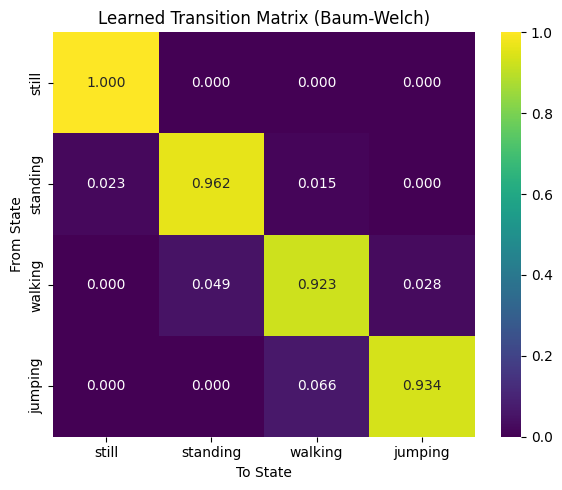

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

# Transition matrix heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(A_trained, annot=True, fmt='.3f', cmap='viridis',
            xticklabels=STATES, yticklabels=STATES, ax=ax)
ax.set_xlabel('To State')
ax.set_ylabel('From State')
ax.set_title('Learned Transition Matrix (Baum-Welch)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'transition_matrix.png'), dpi=150)
plt.show()

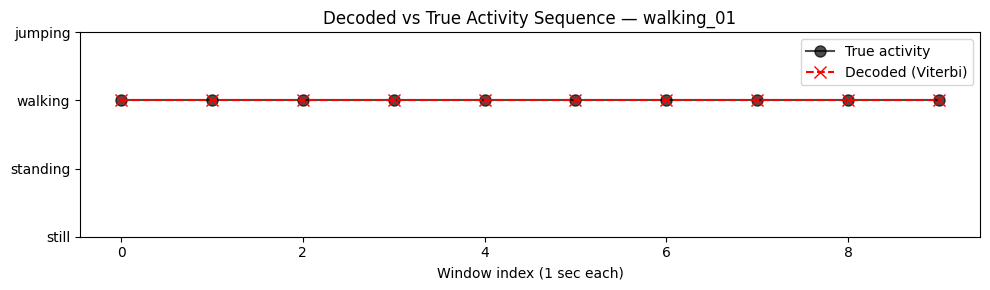

In [13]:
example_take = 'walking_01'
example_df = normalized_df[normalized_df['take_id'] == example_take].sort_values('window_idx')
X_example = example_df[feature_cols].values

decoded_example, _ = viterbi(X_example, pi_trained, A_trained, means_trained, covs_trained)
true_example = example_df['activity'].map(state_to_idx).values

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(true_example, 'o-', label='True activity', color='black', markersize=8, alpha=0.7)
ax.plot(decoded_example, 'x--', label='Decoded (Viterbi)', color='red', markersize=8)
ax.set_yticks(range(N_STATES))
ax.set_yticklabels(STATES)
ax.set_xlabel('Window index (1 sec each)')
ax.set_title(f'Decoded vs True Activity Sequence — {example_take}')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'decoded_sequence_example.png'), dpi=150)
plt.show()

In [14]:
error_takes = []
for take_id, take_df in normalized_df.groupby('take_id'):
    take_df = take_df.sort_values('window_idx')
    X_t = take_df[feature_cols].values
    true_t = take_df['activity'].map(state_to_idx).values
    decoded_t, _ = viterbi(X_t, pi_trained, A_trained, means_trained, covs_trained)
    n_errors = (decoded_t != true_t).sum()
    if n_errors > 0:
        error_takes.append((take_id, n_errors, len(true_t)))

error_takes.sort(key=lambda x: -x[1])
print(error_takes[:10])

[('still_08', 3, 10), ('standing_01', 2, 10), ('standing_03', 2, 10), ('standing_14', 2, 10), ('jumping_01', 1, 10), ('jumping_03', 1, 10), ('jumping_05', 1, 10), ('jumping_09', 1, 10), ('jumping_13', 1, 10), ('jumping_15', 1, 10)]


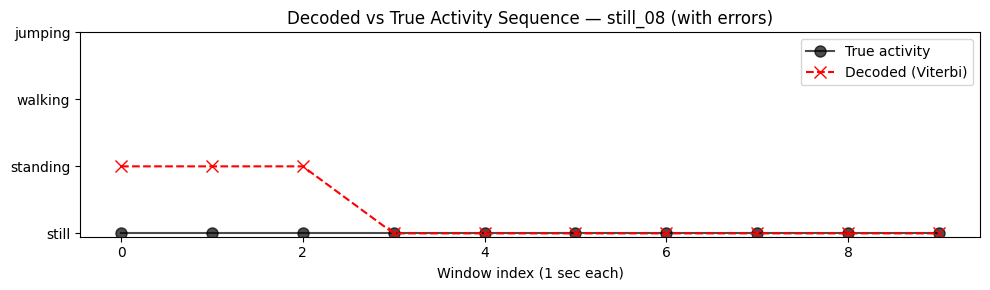

True:    ['still', 'still', 'still', 'still', 'still', 'still', 'still', 'still', 'still', 'still']
Decoded: ['standing', 'standing', 'standing', 'still', 'still', 'still', 'still', 'still', 'still', 'still']


In [15]:
# Pick the top error take from cell 22's error_takes list (or fall back to any take)
if error_takes:
    example_take2 = error_takes[0][0]
else:
    example_take2 = normalized_df['take_id'].iloc[0]

example_df2 = normalized_df[normalized_df['take_id'] == example_take2].sort_values('window_idx')
X_example2 = example_df2[feature_cols].values

decoded_example2, _ = viterbi(X_example2, pi_trained, A_trained, means_trained, covs_trained)
true_example2 = example_df2['activity'].map(state_to_idx).values

fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(true_example2, 'o-', label='True activity', color='black', markersize=8, alpha=0.7)
ax.plot(decoded_example2, 'x--', label='Decoded (Viterbi)', color='red', markersize=8)
ax.set_yticks(range(N_STATES))
ax.set_yticklabels(STATES)
ax.set_xlabel('Window index (1 sec each)')
ax.set_title(f'Decoded vs True Activity Sequence — {example_take2} (with errors)')
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'decoded_sequence_example2.png'), dpi=150)
plt.show()

print('True:   ', [STATES[i] for i in true_example2])
print('Decoded:', [STATES[i] for i in decoded_example2])


In [16]:
# Test data is already present locally — no upload needed.
# (This cell replaced a Google Colab file-upload widget.)
print('Test folder:', os.path.join(DATA_PATH, 'test'))
print('Test files:', sorted(os.listdir(os.path.join(DATA_PATH, 'test'))))


Test folder: /Users/paula/Desktop/Formative2_project/Formative2_data/test
Test files: ['test_jumping_01_accel.csv', 'test_jumping_01_gyro.csv', 'test_jumping_01_meta.csv', 'test_standing_01_accel.csv', 'test_standing_01_gyro.csv', 'test_standing_01_meta.csv', 'test_still_01_accel.csv', 'test_still_01_gyro.csv', 'test_still_01_meta.csv', 'test_walking_01_accel.csv', 'test_walking_01_gyro.csv', 'test_walking_01_meta.csv']


## Evaluation on Unseen Test Data
Four unseen test recordings are loaded — one per activity — and processed through
the identical feature extraction and normalization pipeline used during training.
Viterbi decoding is then applied using the trained model parameters. Because none
of these recordings were used during training or Baum-Welch refinement, this
evaluation measures genuine generalization to new data rather than training-set
memorization.


In [17]:
def load_test_takes(base_path=None):
    if base_path is None:
        base_path = os.path.join(DATA_PATH, 'test')
    accel_files = sorted(glob.glob(f'{base_path}/test_*_accel.csv'))
    all_takes = []

    for accel_path in accel_files:
        take_id = accel_path.split('_accel.csv')[0].split('/')[-1]
        gyro_path = accel_path.replace('_accel.csv', '_gyro.csv')

        accel = pd.read_csv(accel_path)
        gyro = pd.read_csv(gyro_path)

        accel = accel.rename(columns={'x':'accel_x','y':'accel_y','z':'accel_z'})
        gyro = gyro.rename(columns={'x':'gyro_x','y':'gyro_y','z':'gyro_z'})

        merged = pd.merge_asof(
            accel.sort_values('seconds_elapsed'),
            gyro[['seconds_elapsed','gyro_x','gyro_y','gyro_z']].sort_values('seconds_elapsed'),
            on='seconds_elapsed',
            direction='nearest'
        )

        # Extract true activity from take_id
        true_activity = take_id.replace('test_', '').rsplit('_', 1)[0]
        merged['activity'] = true_activity
        merged['take_id'] = take_id
        all_takes.append(merged)

    return pd.concat(all_takes, ignore_index=True)

test_df = load_test_takes()
print(test_df.shape)
print(test_df['activity'].value_counts())

test_feature_df = build_feature_dataset(test_df)
print("\nTest feature shape:", test_feature_df.shape)

X_test = scaler.transform(test_feature_df[feature_cols])
test_normalized_df = pd.DataFrame(X_test, columns=feature_cols)
test_normalized_df['activity'] = test_feature_df['activity'].values
test_normalized_df['take_id'] = test_feature_df['take_id'].values
test_normalized_df['window_idx'] = test_feature_df['window_idx'].values

print(test_normalized_df['activity'].value_counts())

(3169, 10)
activity
jumping     820
standing    796
walking     786
still       767
Name: count, dtype: int64

Test feature shape: (61, 19)
activity
jumping     16
standing    15
still       15
walking     15
Name: count, dtype: int64


## Per-Activity Metrics and Confusion Matrix
Unseen test sequences are decoded with Viterbi and predictions are compared against
ground-truth labels. Sensitivity (recall per class), specificity (true-negative rate
per class), and per-class accuracy are reported. A confusion matrix is provided to
show the full pattern of correct and incorrect classifications.


In [18]:
from sklearn.metrics import confusion_matrix

# Decode each test take separately
all_true = []
all_pred = []

for take_id, take_df in test_normalized_df.groupby('take_id'):
    take_df = take_df.sort_values('window_idx')
    X_t = take_df[feature_cols].values
    true_t = take_df['activity'].map(state_to_idx).values
    decoded_t, _ = viterbi(X_t, pi_trained, A_trained, means_trained, covs_trained)

    all_true.extend(true_t)
    all_pred.extend(decoded_t)

all_true = np.array(all_true)
all_pred = np.array(all_pred)

overall_accuracy = (all_true == all_pred).mean()
print(f"Overall test accuracy: {overall_accuracy:.3f}\n")

# Confusion matrix
cm = confusion_matrix(all_true, all_pred, labels=range(N_STATES))
cm_df = pd.DataFrame(cm, index=STATES, columns=STATES)
print("Confusion Matrix:")
print(cm_df)

# Per-activity sensitivity, specificity, accuracy
print("\nPer-Activity Metrics:")
results = []
for i, state in enumerate(STATES):
    n_samples = (all_true == i).sum()
    if n_samples == 0:
        continue  # skip activities not present in test set

    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP

    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0
    accuracy = (TP + TN) / cm.sum()

    results.append({
        'Activity': state,
        'N Samples': n_samples,
        'Sensitivity': round(sensitivity, 3),
        'Specificity': round(specificity, 3),
        'Accuracy': round(accuracy, 3)
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

Overall test accuracy: 0.902

Confusion Matrix:
          still  standing  walking  jumping
still        15         0        0        0
standing      0        10        4        1
walking       0         0       14        1
jumping       0         0        0       16

Per-Activity Metrics:
Activity  N Samples  Sensitivity  Specificity  Accuracy
   still         15        1.000        1.000     1.000
standing         15        0.667        1.000     0.918
 walking         15        0.933        0.913     0.918
 jumping         16        1.000        0.956     0.967


## Emission Distribution and Confusion Matrix Visualizations
The confusion matrix is visualized as a heatmap for clarity. The learned emission
distributions are represented as a heatmap of per-state mean values across all
features (emission means), illustrating how each hidden state's typical sensor
signature differs across the feature space.


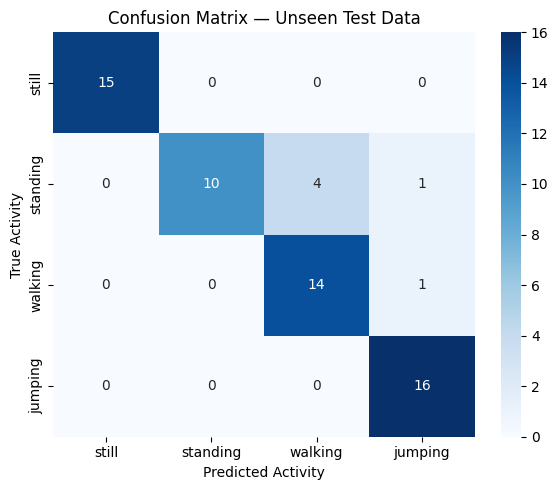

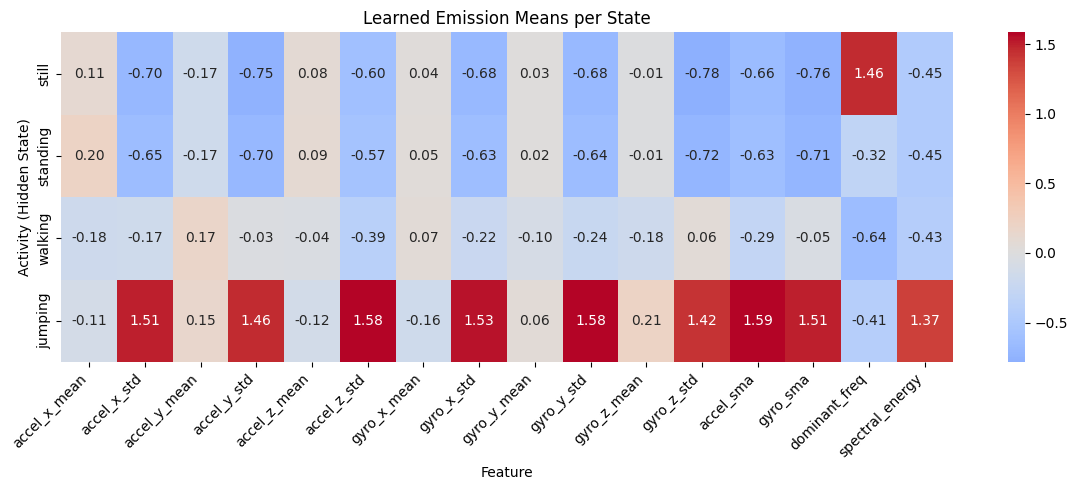

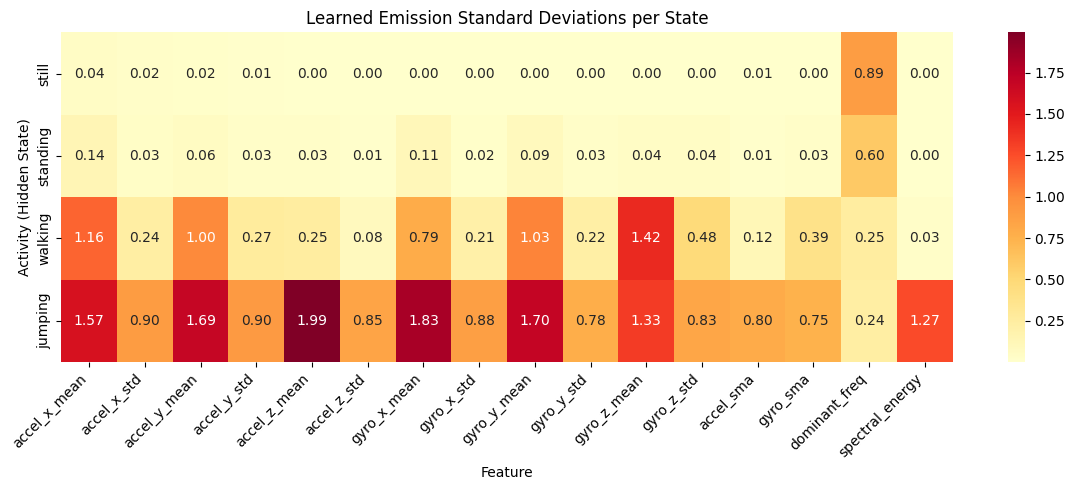

In [19]:
# Confusion matrix heatmap
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted Activity')
ax.set_ylabel('True Activity')
ax.set_title('Confusion Matrix — Unseen Test Data')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'confusion_matrix.png'), dpi=150)
plt.show()

# Emission means heatmap (shows what each state's "typical" feature signature looks like)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(means_trained, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            xticklabels=feature_cols, yticklabels=STATES, ax=ax)
ax.set_xlabel('Feature')
ax.set_ylabel('Activity (Hidden State)')
ax.set_title('Learned Emission Means per State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'emission_means.png'), dpi=150)
plt.show()
# Emission standard deviations heatmap (sqrt of stored variances)
stds_trained = np.sqrt(covs_trained)
fig, ax = plt.subplots(figsize=(12, 5))
sns.heatmap(stds_trained, annot=True, fmt='.2f', cmap='YlOrRd',
            xticklabels=feature_cols, yticklabels=STATES, ax=ax)
ax.set_xlabel('Feature')
ax.set_ylabel('Activity (Hidden State)')
ax.set_title('Learned Emission Standard Deviations per State')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'emission_stds.png'), dpi=150)
plt.show()


## Raw Sensor Data Visualization
Raw accelerometer signals are visualized below for one representative take per
activity, illustrating the distinct motion signatures that characterize each
activity class in the sensor data.


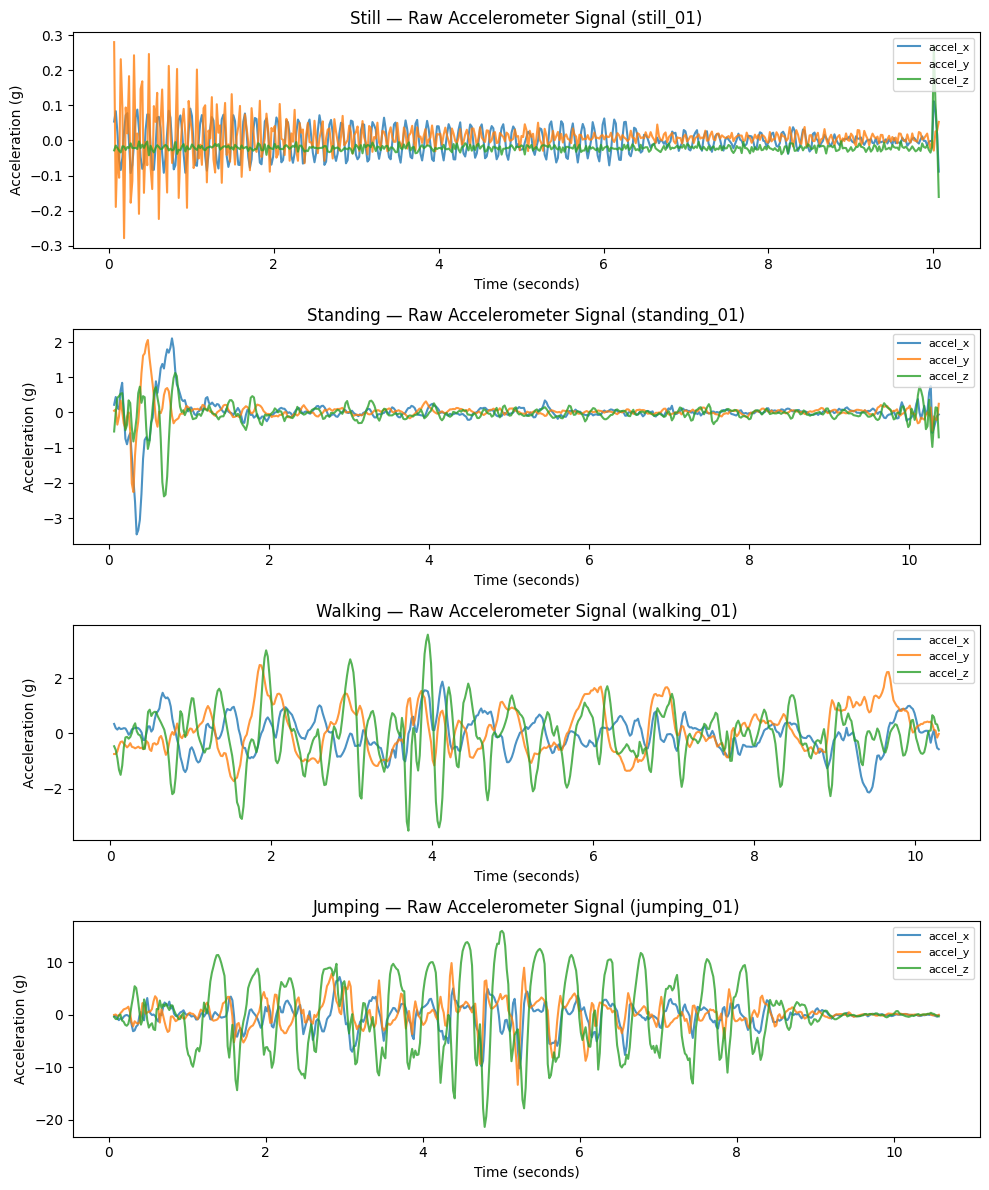

In [20]:
available_activities = df['activity'].unique().tolist()
sample_takes = {}
for act in available_activities:
    first_take = df[df['activity'] == act]['take_id'].iloc[0]
    sample_takes[act] = first_take

fig, axes = plt.subplots(len(sample_takes), 1,
                          figsize=(10, 3 * len(sample_takes)), sharex=False)
if len(sample_takes) == 1:
    axes = [axes]

for ax, (activity, take_id) in zip(axes, sample_takes.items()):
    take_data = df[df['take_id'] == take_id].sort_values('seconds_elapsed')
    ax.plot(take_data['seconds_elapsed'], take_data['accel_x'], label='accel_x', alpha=0.8)
    ax.plot(take_data['seconds_elapsed'], take_data['accel_y'], label='accel_y', alpha=0.8)
    ax.plot(take_data['seconds_elapsed'], take_data['accel_z'], label='accel_z', alpha=0.8)
    ax.set_title(f'{activity.capitalize()} — Raw Accelerometer Signal ({take_id})')
    ax.set_ylabel('Acceleration (g)')
    ax.set_xlabel('Time (seconds)')
    ax.legend(loc='upper right', fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_PATH, 'raw_signal_samples.png'), dpi=150)
plt.show()
